<a href="https://colab.research.google.com/github/RAFA-CK/RAFA-CK/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving GROUP 3.xlsx to GROUP 3.xlsx


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
# Use second row as column names
df.columns = df.iloc[1]

# Remove first two rows
df = df.drop([0,1])

# Reset index
df = df.reset_index(drop=True)

df.head()

1,NaN,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,22000.0,200000,2,2,2,28,0,0,0,0,...,66029,66836,68390,3000,3000,3000,2500,2632,2700,0
1,22001.0,50000,2,2,1,28,0,0,2,2,...,49571,50028,17159,5000,2000,0,1809,35082,2000,0
2,22002.0,260000,2,1,2,28,-2,-2,-2,-2,...,1557,685,11625,5763,703,1564,688,11683,6997,0
3,22003.0,250000,2,2,2,29,0,-1,-1,-2,...,-38,7581,5625,14158,0,0,7619,5653,652,0
4,22004.0,230000,2,1,2,29,-2,-1,2,-1,...,4571,2526,5375,11142,1430,4571,2526,5375,3133,0


In [5]:
# Remove the first column (ID column)
df = df.drop(df.columns[0], axis=1)

df.head()

1,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,200000,2,2,2,28,0,0,0,0,0,...,66029,66836,68390,3000,3000,3000,2500,2632,2700,0
1,50000,2,2,1,28,0,0,2,2,0,...,49571,50028,17159,5000,2000,0,1809,35082,2000,0
2,260000,2,1,2,28,-2,-2,-2,-2,-2,...,1557,685,11625,5763,703,1564,688,11683,6997,0
3,250000,2,2,2,29,0,-1,-1,-2,-1,...,-38,7581,5625,14158,0,0,7619,5653,652,0
4,230000,2,1,2,29,-2,-1,2,-1,-1,...,4571,2526,5375,11142,1430,4571,2526,5375,3133,0


In [6]:
df = df.apply(pd.to_numeric)

In [7]:
X = df.drop("Y", axis=1)
y = df["Y"]

In [9]:
# 6. Split features and target
# ==============================

X = df.drop("Y", axis=1)
y = df["Y"]

In [10]:
# 7. Train-test split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# 8. Feature scaling
# ==============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# 9. Train Logistic Regression
# ==============================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)



LogisticRegression(max_iter=1000)

In [15]:
# Create a table for coefficients
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

print("Logistic Regression Coefficients:")
print(coefficients)

Logistic Regression Coefficients:
   Variable  Coefficient
0        X1    -0.197997
1        X2    -0.016972
2        X3    -0.141056
3        X4    -0.092199
4        X5     0.105227
5        X6     0.606058
6        X7    -0.105001
7        X8     0.224493
8        X9    -0.156156
9       X10     0.195396
10      X11    -0.068537
11      X12    -0.987825
12      X13     0.465562
13      X14     0.518018
14      X15     0.442700
15      X16    -0.249762
16      X17    -0.100479
17      X18    -0.021991
18      X19    -0.022994
19      X20    -0.280197
20      X21     0.145923
21      X22    -0.663805
22      X23    -0.366057


In [16]:
import numpy as np

# Add odds ratio column
coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])

print("Coefficients with Odds Ratios:")
print(coefficients)

Coefficients with Odds Ratios:
   Variable  Coefficient  Odds_Ratio
0        X1    -0.197997    0.820372
1        X2    -0.016972    0.983171
2        X3    -0.141056    0.868441
3        X4    -0.092199    0.911924
4        X5     0.105227    1.110963
5        X6     0.606058    1.833190
6        X7    -0.105001    0.900323
7        X8     0.224493    1.251687
8        X9    -0.156156    0.855426
9       X10     0.195396    1.215792
10      X11    -0.068537    0.933759
11      X12    -0.987825    0.372386
12      X13     0.465562    1.592910
13      X14     0.518018    1.678697
14      X15     0.442700    1.556906
15      X16    -0.249762    0.778986
16      X17    -0.100479    0.904404
17      X18    -0.021991    0.978249
18      X19    -0.022994    0.977268
19      X20    -0.280197    0.755635
20      X21     0.145923    1.157107
21      X22    -0.663805    0.514888
22      X23    -0.366057    0.693463


In [13]:
# 10. Predictions
# ==============================

y_pred = model.predict(X_test)

In [14]:
# 11. Model Evaluation
# ==============================

print("Model Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy:
0.8507462686567164

Confusion Matrix:
[[168   1]
 [ 29   3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       169
           1       0.75      0.09      0.17        32

    accuracy                           0.85       201
   macro avg       0.80      0.54      0.54       201
weighted avg       0.84      0.85      0.80       201



AUC Score: 0.6079881656804733


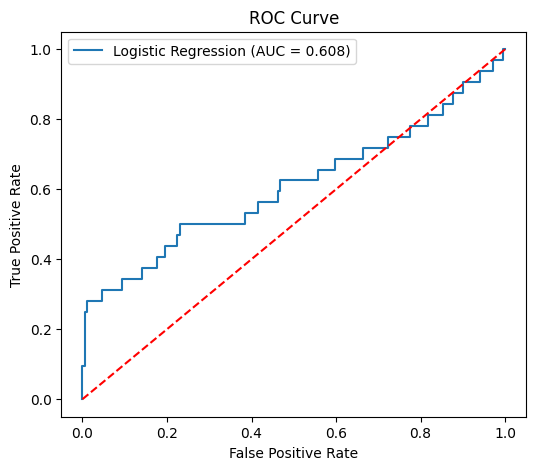

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability predictions
y_prob = model.predict_proba(X_test)[:,1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression (AUC = %.3f)" % auc_score)
plt.plot([0,1], [0,1], 'r--')  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()